In [200]:
import tensorflow as tf
import numpy as np
import os
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 16})

In [189]:
path = r'C:\Users\Voland\Desktop\art\oop1\models/'

In [190]:
modeltheta = tf.keras.models.load_model(f"{path}modeltheta")
modelphi   = tf.keras.models.load_model(f"{path}modelphi")
modelh     = tf.keras.models.load_model(f"{path}modelh")
modelgamma = tf.keras.models.load_model(f"{path}modelgamma")


In [191]:
x = np.loadtxt('x_p.txt').reshape(-1,1)
y = np.loadtxt('y_p.txt').reshape(-1,1)
xx,yy = np.meshgrid(x, y)
t = np.linspace(1.0,1.0,len(x)).reshape(-1,1)
X = np.concatenate([x,y,t],1)
X

array([[0.    , 0.    , 1.    ],
       [0.0101, 0.    , 1.    ],
       [0.0202, 0.    , 1.    ],
       ...,
       [0.9798, 1.    , 1.    ],
       [0.9899, 1.    , 1.    ],
       [1.    , 1.    , 1.    ]])

In [192]:
theta_fem = np.loadtxt('theta.txt').reshape(-1,1)
phi_fem  = np.loadtxt('phi.txt').reshape(-1,1)
theta_pinn = modeltheta(X)
phi_pinn = modelphi(X)

In [201]:
path = r'C:\Users\Voland\Desktop\art\oop1\FreeFem/'
os.makedirs(path, exist_ok=True)   # safe even if folder exists


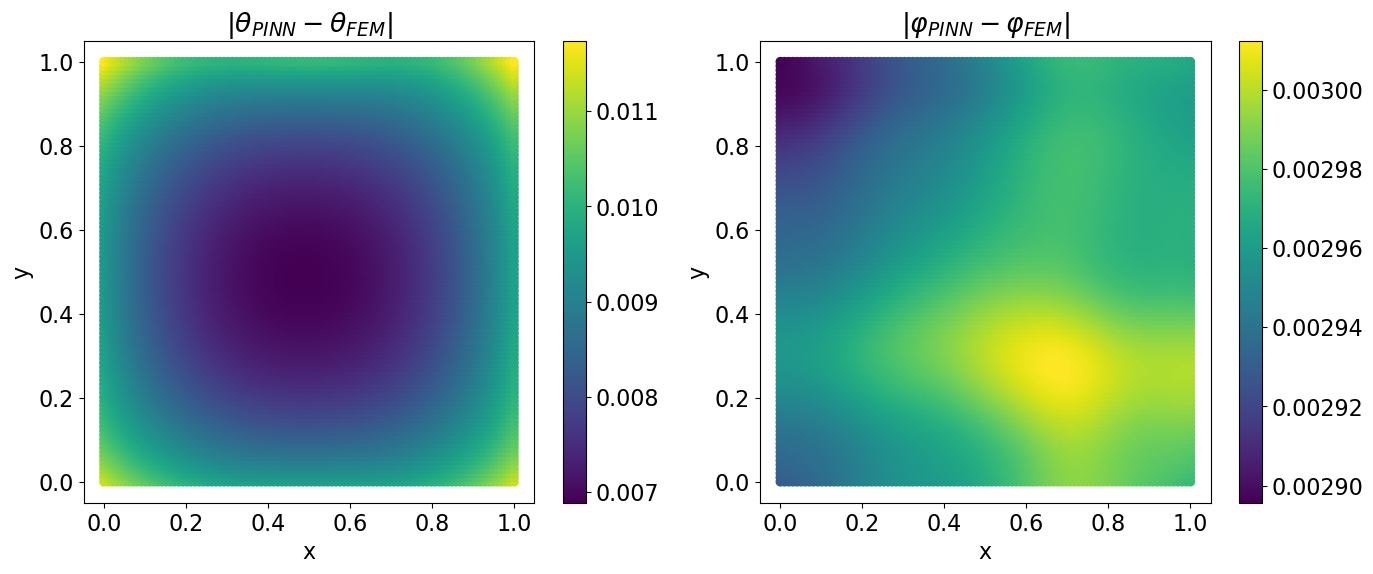

In [202]:
fig, axes = plt.subplots( ncols=2, figsize=(16, 6))
img1 = axes[0].scatter(x,y,c=np.abs(theta_fem-theta_pinn))
img2 = axes[1].scatter(x,y,c=np.abs(phi_fem-phi_pinn))       
axes[0].set_title('$|\\theta_{PINN}-\\theta_{FEM}|$')  
cb1 = fig.colorbar(img1, ax=axes[0])  # Just shows colorbar for the last one — optional 
axes[1].set_title('$|\\varphi_{PINN}-\\varphi_{FEM}|$')  
cb2 = fig.colorbar(img2, ax=axes[1])  # Just shows colorbar for the last one — optional
axes[0].set_xlabel('x')
axes[1].set_xlabel('x')
axes[0].set_ylabel('y')
axes[1].set_ylabel('y')
plt.savefig(f"{path}/comparison.png", bbox_inches='tight', dpi=300)